# 08 - DS EDA, Segmentation, PrÃ©processing et Feature Engineering

Objectif: justifier les transformations et les features Ã  partir d'observations statistiques et mÃ©tier.


**Convention de commentaire dans ce notebook (Ã  respecter dans l'analyse)**

- `Constat` : ce que montrent les chiffres/graphes
- `InterprÃ©tation` : ce que cela signifie (avec prudence)
- `DÃ©cision` : impact pratique sur preprocessing / CV / modÃ¨le
- Terminer chaque bloc par une phrase `Impact modÃ¨le attendu`


In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR
for _candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (_candidate / "src").exists() and (_candidate / "data").exists():
        ROOT = _candidate
        break
else:
    raise RuntimeError("Project root not found. Expected folders: src/ and data/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ARTIFACTS_DIR = ROOT / "artifacts"
    
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
from src.insurance_pricing.training import ensure_dir



import src.insurance_pricing.training as v2
from src.insurance_pricing.analytics import *

DATA_DIR = ROOT / "data"
ARTIFACT_DS = ensure_dir(ROOT / DEFAULT_DS_DIR)
ARTIFACT_V2 = ROOT / v2.DEFAULT_V2_DIR

SEED = 42
QUICK_ANALYSIS = True
FULL_ANALYSIS = False
SAMPLE_N = 3000
np.random.seed(SEED)


In [2]:
train_raw, test_raw = load_project_datasets(DATA_DIR)
print("train:", train_raw.shape, "test:", test_raw.shape)
display(train_raw.head(2))
display(test_raw.head(2))


train: (50000, 33) test: (50000, 28)


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,...,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,0,A00000001,V01,A00000001-V01,0.5,Maxi,29,9,Biannual,No,...,PEUGEOT,306,10,9,182,Tourism,20700,1210,0,0.0
1,1,A00000002,V01,A00000002-V01,0.5,Maxi,3,1,Biannual,No,...,MERCEDES BENZ,C220,4,2,229,Tourism,34250,1510,0,0.0


,index,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,...,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule
0,50000,0.58,Maxi,1,1,Yearly,No,Retired,28388,No,...,55,Gasoline,RENAULT,CLIO,16,15,150,Tourism,10321,830
1,50001,0.50,Median2,2,2,Yearly,No,Retired,19123,No,...,96,Diesel,MERCEDES BENZ,C220,16,12,175,Tourism,24652,1400


In [3]:
feature_sets = v2.prepare_feature_sets(train_raw, test_raw, rare_min_count=30, drop_identifiers=True)
bundle = feature_sets["base_v2"]
print("feature sets:", {k: (len(v.feature_cols), len(v.cat_cols), len(v.num_cols)) for k, v in feature_sets.items()})


feature sets: {'base_v2': (47, 18, 29), 'robust_v2': (44, 15, 29), 'compact_v2': (43, 14, 29)}


In [4]:
# Typage enrichi + cardinalitÃ©
data_dict = build_data_dictionary(train_raw, test_raw)
col_types = classify_columns(train_raw, test_raw)
cardinality = build_cardinality_report(train_raw, test_raw)
display(col_types)
display(cardinality.head(25))


,column,present_train,present_test,dtype_train,dtype_test,nunique_train,nunique_test,missing_rate_train,missing_rate_test,sample_values_train,role_guess,is_target,is_id_like,is_categorical,is_numeric,high_cardinality_train
0,code_postal,1,1,object,object,12790,12806.0,0.00000,0.00000,36233 | 92073 | 92026,categorical,0,0,1,0,1
1,conducteur2,1,1,object,object,2,2.0,0.00000,0.00000,No | No | No,categorical,0,0,1,0,0
2,essence_vehicule,1,1,object,object,3,3.0,0.00000,0.00000,Gasoline | Diesel | Gasoline,categorical,0,0,1,0,0
3,freq_paiement,1,1,object,object,4,4.0,0.00000,0.00000,Biannual | Biannual | Yearly,categorical,0,0,1,0,0
4,marque_vehicule,1,1,object,object,89,88.0,0.00000,0.00000,PEUGEOT | MERCEDES BENZ | BMW,categorical,0,0,1,0,0
5,modele_vehicule,1,1,object,object,886,894.0,0.00000,0.00000,306 | C220 | Z3,categorical,0,0,1,0,1
6,paiement,1,1,object,object,2,2.0,0.00000,0.00000,No | No | No,categorical,0,0,1,0,0
7,sex_conducteur1,1,1,object,object,2,2.0,0.00000,0.00000,M | M | M,categorical,0,0,1,0,0
8,sex_conducteur2,1,1,object,object,3,3.0,0.66812,0.66816,F | M | F,categorical,0,0,1,0,0
9,type_contrat,1,1,object,object,4,4.0,0.00000,0.00000,Maxi | Maxi | Maxi,categorical,0,0,1,0,0


,column,dtype_train,nunique_train,nunique_test,top1_ratio_train,rare_ratio_train_lt10
0,index,int64,50000,50000.0,0.00002,1.000000
1,id_contrat,object,50000,NaN,0.00002,1.000000
2,id_client,object,45785,NaN,0.00010,1.000000
3,code_postal,object,12790,12806.0,0.00490,0.928225
4,prix_vehicule,int64,4752,4691.0,0.01014,0.780934
5,montant_sinistre,float64,2260,NaN,0.94166,0.996018
6,poids_vehicule,int64,968,959.0,0.03766,0.501033
7,modele_vehicule,object,886,894.0,0.07214,0.586907
8,cylindre_vehicule,int64,532,521.0,0.06476,0.535714
9,din_vehicule,int64,207,205.0,0.09224,0.352657


In [5]:
# Statistiques univariÃ©es numÃ©riques
num_cols = [c for c in train_raw.columns if str(train_raw[c].dtype).startswith(("int","float"))]
num_cols_eda = [c for c in num_cols if c not in [v2.TARGET_FREQ_COL]]
rows = []
for c in num_cols_eda:
    s = pd.to_numeric(train_raw[c], errors="coerce").replace([np.inf,-np.inf], np.nan).dropna()
    if len(s) == 0:
        continue
    rows.append({
        "column": c,
        "n": int(len(s)),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std(ddof=0)),
        "iqr": float(s.quantile(0.75) - s.quantile(0.25)),
        "mad": float(np.median(np.abs(s - s.median()))),
        "skew": float(stats.skew(s)) if len(s) > 2 else np.nan,
        "kurtosis": float(stats.kurtosis(s)) if len(s) > 3 else np.nan,
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "p50": float(s.quantile(0.50)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
    })
uni_num = pd.DataFrame(rows).sort_values("skew", ascending=False)
display(uni_num.head(20))


,column,n,mean,median,std,iqr,mad,skew,kurtosis,p01,p05,p50,p95,p99
16,montant_sinistre,50000,103.369344,0.0,545.397425,0.0,0.0,10.146564,187.028429,0.00,0.00,0.0,764.236,2683.76
1,bonus,50000,0.537911,0.5,0.098998,0.0,0.0,3.440619,14.650131,0.50,0.50,0.5,0.760,0.95
7,anciennete_permis2,50000,9.139800,0.0,17.059321,15.0,0.0,2.567973,9.186628,0.00,0.00,0.0,43.000,59.00
3,anciennete_info,50000,2.726860,2.0,2.348535,2.0,1.0,2.438832,8.324153,1.00,1.00,2.0,7.000,12.00
14,prix_vehicule,50000,18095.562080,16250.0,8715.016777,10200.0,4800.0,2.027298,10.586471,3771.00,8522.00,16250.0,33450.000,47900.00
11,debut_vente_vehicule,50000,11.628320,10.0,7.756015,9.0,4.0,1.663858,4.741198,1.00,2.00,10.0,27.000,41.00
10,din_vehicule,50000,91.547520,87.0,34.489591,41.0,21.0,1.634912,6.225890,30.00,51.00,87.0,150.000,210.00
8,anciennete_vehicule,49999,9.531091,8.0,7.012082,9.0,4.0,1.472460,4.035710,1.00,1.00,8.0,22.000,33.00
12,fin_vente_vehicule,50000,8.653180,7.0,6.619835,8.0,4.0,1.374192,3.453905,1.00,1.00,7.0,21.000,30.00
9,cylindre_vehicule,50000,1647.795820,1587.0,463.643996,550.0,309.0,1.199923,5.450556,652.00,998.00,1587.0,2477.000,2993.00


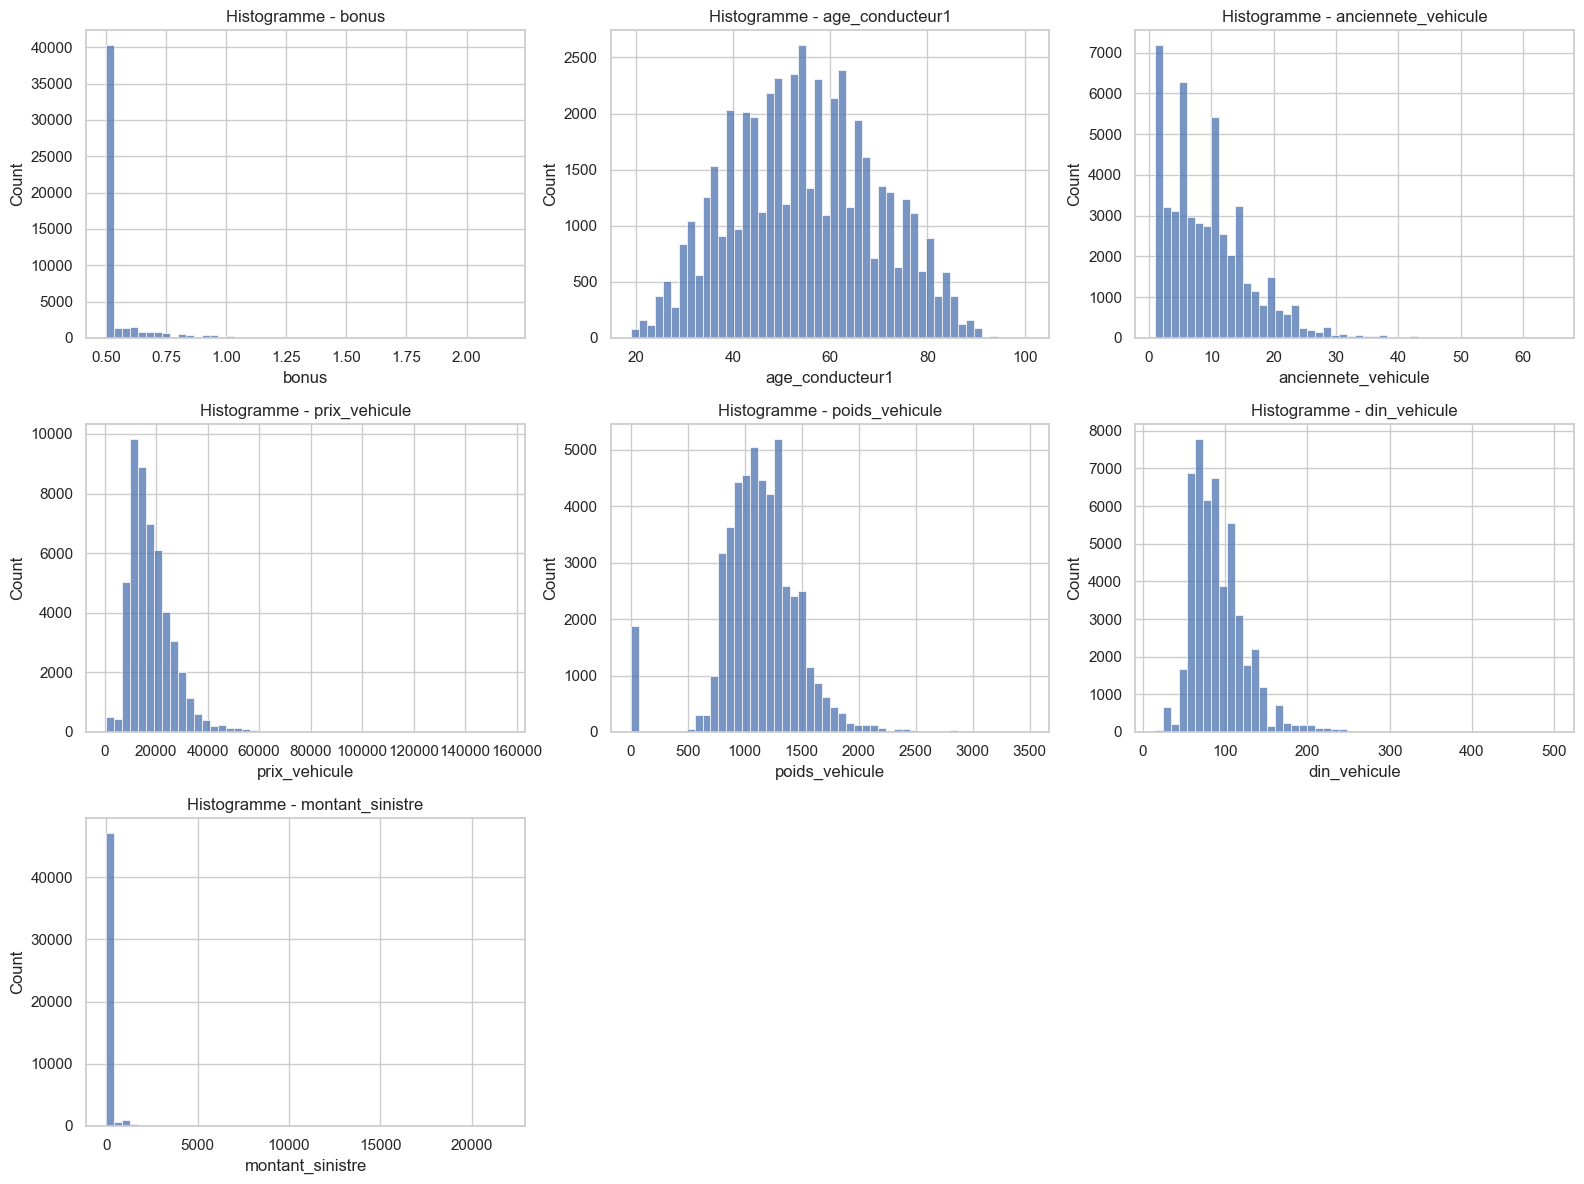

In [6]:
# Visualisations univariÃ©es (Ã©chantillon de variables numÃ©riques)
plot_num_cols = [c for c in ["bonus","age_conducteur1","anciennete_vehicule","prix_vehicule","poids_vehicule","din_vehicule",v2.TARGET_SEV_COL] if c in train_raw.columns]
ncols = 3
nrows = int(np.ceil(len(plot_num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)
for ax, c in zip(axes, plot_num_cols):
    s = pd.to_numeric(train_raw[c], errors='coerce')
    sns.histplot(s, bins=50, ax=ax)
    ax.set_title(f"Histogramme - {c}")
for ax in axes[len(plot_num_cols):]:
    ax.axis("off")
plt.tight_layout()


**Ã€ commenter (univariÃ©)**
- `Constat`: asymÃ©trie, valeurs extrÃªmes, distributions tronquÃ©es.
- `InterprÃ©tation`: impact sur choix de mÃ©triques et transformations.
- `DÃ©cision`: `log1p`, winsorisation d'apprentissage, modÃ¨les robustes.


In [7]:
# Statistiques catÃ©gorielles + raretÃ©
cat_cols = [c for c in train_raw.columns if train_raw[c].dtype == "object"]
cat_rows = []
for c in cat_cols:
    vc = train_raw[c].astype(str).value_counts(dropna=False)
    cat_rows.append({
        "column": c,
        "nunique": int(vc.size),
        "top1": str(vc.index[0]) if len(vc) else "",
        "top1_ratio": float(vc.iloc[0] / max(len(train_raw), 1)) if len(vc) else np.nan,
        "rare_levels_lt10": int((vc < 10).sum()),
        "rare_levels_ratio_lt10": float((vc < 10).sum() / max(len(vc), 1)) if len(vc) else np.nan,
    })
cat_stats = pd.DataFrame(cat_rows).sort_values("nunique", ascending=False)
display(cat_stats)


,column,nunique,top1,top1_ratio,rare_levels_lt10,rare_levels_ratio_lt10
2,id_contrat,50000,A00000001-V01,0.00002,50000,1.000000
0,id_client,45785,A00033051,0.00010,45785,1.000000
7,code_postal,12790,31555,0.00490,11872,0.928225
13,modele_vehicule,886,CLIO,0.07214,520,0.586907
12,marque_vehicule,89,RENAULT,0.26634,38,0.426966
1,id_vehicule,5,V01,0.91570,1,0.200000
3,type_contrat,4,Maxi,0.64720,0,0.000000
4,freq_paiement,4,Yearly,0.37896,0,0.000000
6,utilisation,4,WorkPrivate,0.65882,0,0.000000
11,essence_vehicule,3,Diesel,0.54952,0,0.000000


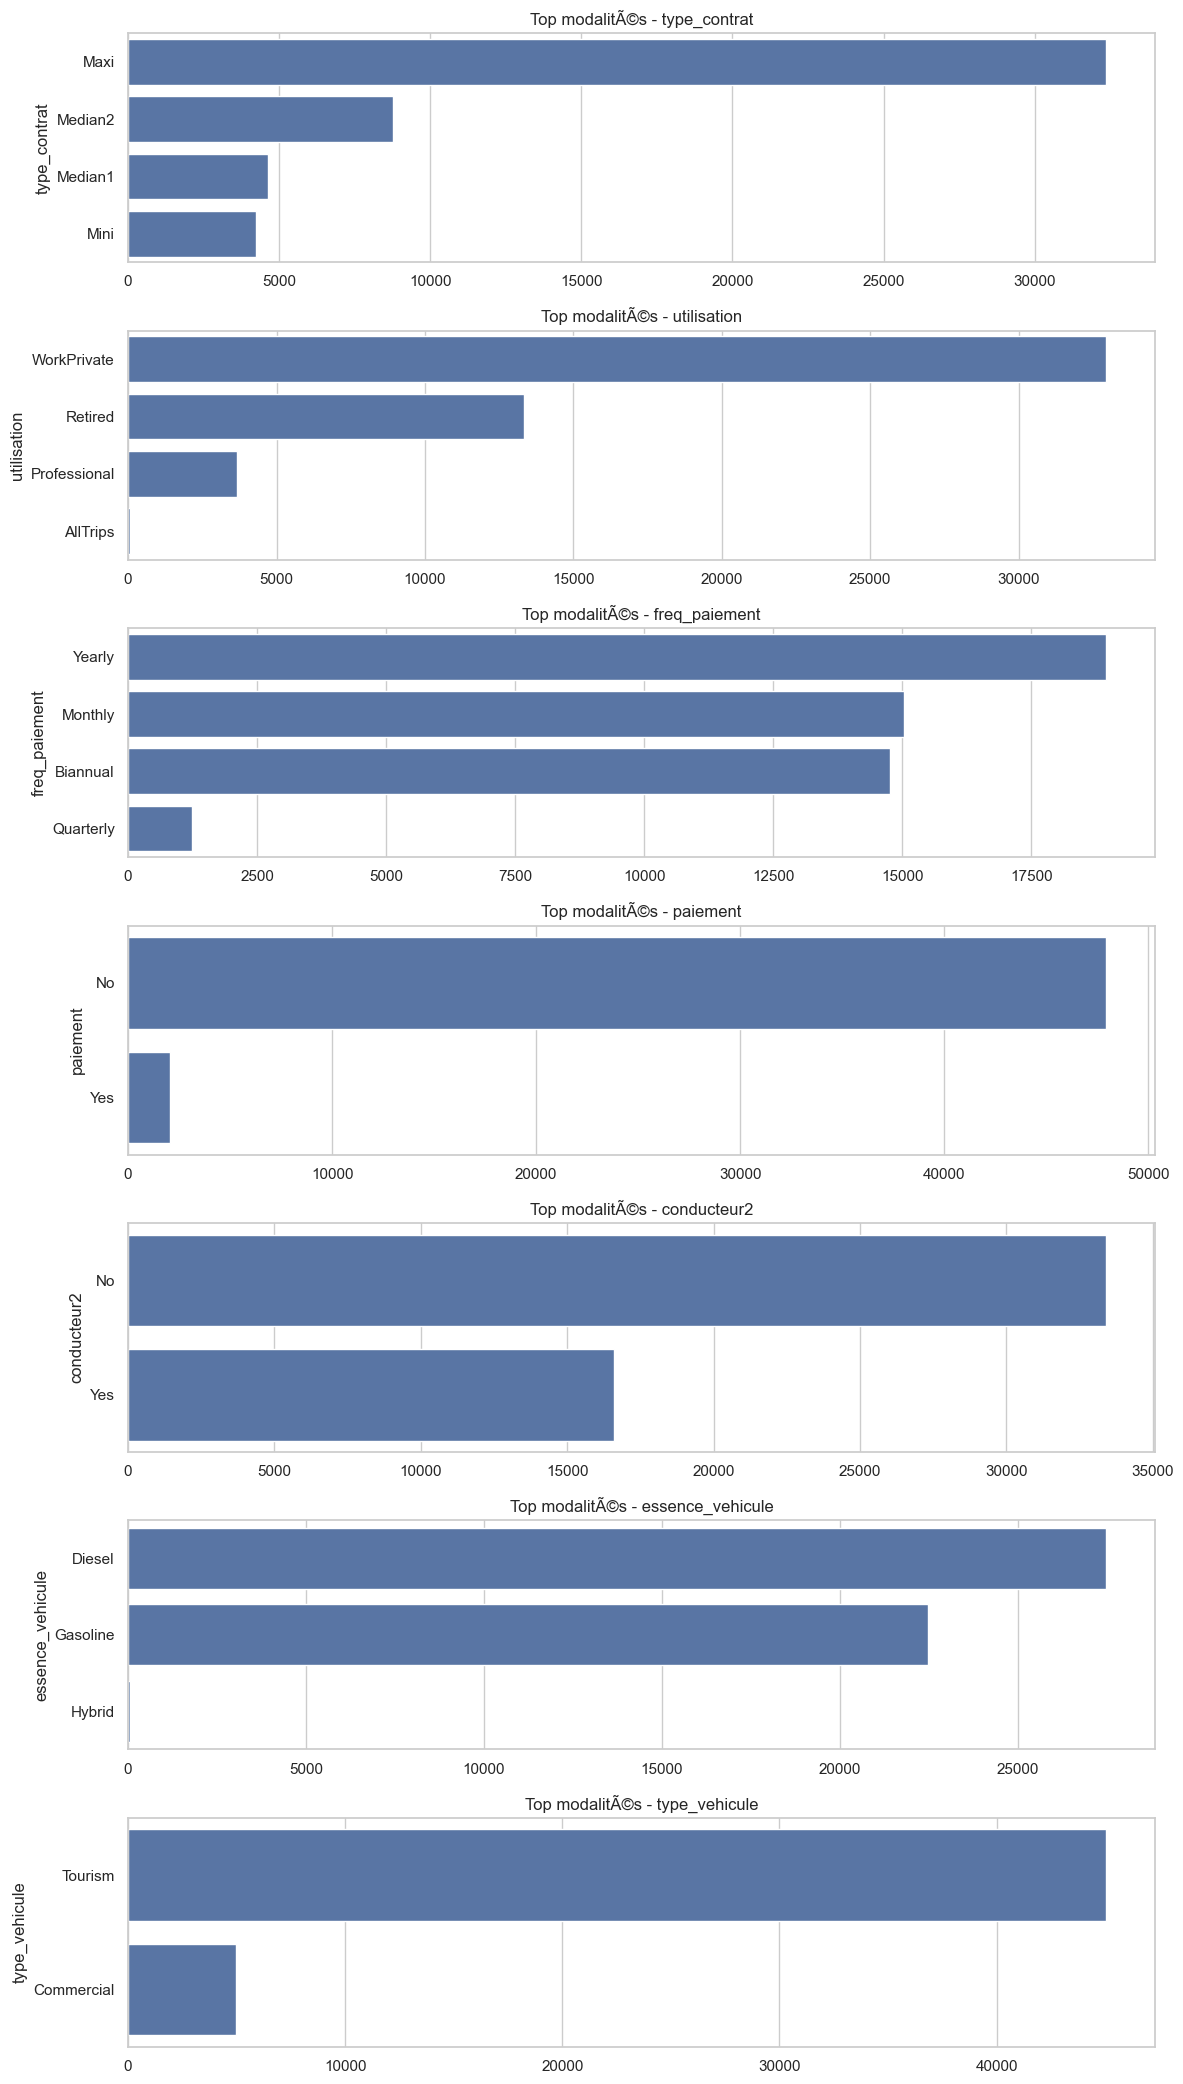

In [8]:
# Barplots catÃ©gorielles (frÃ©quences)
plot_cat_cols = [c for c in ["type_contrat","utilisation","freq_paiement","paiement","conducteur2","essence_vehicule","type_vehicule"] if c in train_raw.columns]
fig, axes = plt.subplots(len(plot_cat_cols), 1, figsize=(12, 3 * len(plot_cat_cols)))
if len(plot_cat_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, plot_cat_cols):
    vc = train_raw[c].astype(str).value_counts(dropna=False).head(15)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax)
    ax.set_title(f"Top modalitÃ©s - {c}")
plt.tight_layout()


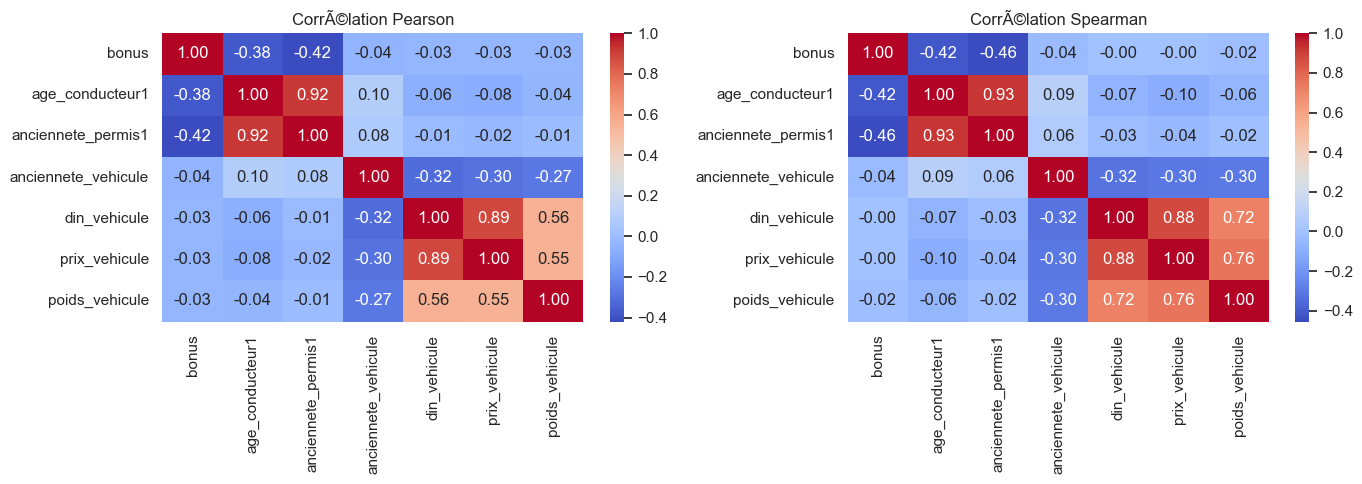

In [9]:
# Analyse bivariÃ©e num-num (Pearson / Spearman) sur sous-ensemble
num_subset = [c for c in ["bonus","age_conducteur1","anciennete_permis1","anciennete_vehicule","din_vehicule","prix_vehicule","poids_vehicule"] if c in train_raw.columns]
corr_pearson = train_raw[num_subset].corr(method="pearson")
corr_spearman = train_raw[num_subset].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("CorrÃ©lation Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("CorrÃ©lation Spearman")
plt.tight_layout()


In [10]:
# Analyse cat-cat (Cramer's V)
cat_subset = [c for c in ["type_contrat","utilisation","freq_paiement","paiement","essence_vehicule","type_vehicule","marque_vehicule"] if c in train_raw.columns]
cramers_v = compute_cramers_v_table(train_raw, cat_cols=cat_subset, max_cols=12)
display(cramers_v.head(20))


,col_a,col_b,cramers_v
0,utilisation,type_vehicule,0.249034
1,type_contrat,type_vehicule,0.247335
2,type_vehicule,marque_vehicule,0.236115
3,essence_vehicule,type_vehicule,0.204121
4,essence_vehicule,marque_vehicule,0.183738
5,utilisation,paiement,0.153309
6,type_contrat,marque_vehicule,0.121215
7,utilisation,freq_paiement,0.117696
8,utilisation,marque_vehicule,0.092623
9,utilisation,essence_vehicule,0.091228


**Rappel mÃ©thodologique**

- CorrÃ©lation / association descriptive `!=` causalitÃ©.
- Ces analyses servent Ã  guider le preprocessing et le feature engineering, pas Ã  conclure sur des relations causales.


In [11]:
# Analyse cible par segments (frÃ©quence / sÃ©vÃ©ritÃ© / pure premium)
train_fe = v2.add_engineered_features(train_raw.copy())
segment_cols = [c for c in ["utilisation","type_contrat","cp2","cp3","marque_vehicule","type_vehicule"] if c in train_fe.columns]
seg_tables = compute_segment_target_tables(train_fe, segment_cols=segment_cols)
for name, df_seg in seg_tables.items():
    print(f"Segment: {name}")
    display(df_seg.head(10))


Segment: utilisation


,segment_col,segment_value,n,claim_rate,severity_mean_pos,severity_median_pos,severity_q95_pos,severity_q99_pos,pure_premium_obs
0,utilisation,AllTrips,48,0.125000,1362.991667,1286.205,1782.9575,1853.6235,170.373958
1,utilisation,Professional,3667,0.078811,1935.354913,1261.560,5138.8140,7190.3480,152.527289
2,utilisation,Retired,13344,0.060177,1663.779128,1236.000,3877.5620,5340.0402,100.121001
3,utilisation,WorkPrivate,32941,0.055220,1794.918659,1236.000,4492.9490,7503.7066,99.115298


Segment: type_contrat


,segment_col,segment_value,n,claim_rate,severity_mean_pos,severity_median_pos,severity_q95_pos,severity_q99_pos,pure_premium_obs
0,type_contrat,Maxi,32360,0.074815,1845.045171,1296.47,4527.380,7047.8660,138.036290
1,type_contrat,Median1,4638,0.029970,1513.196547,1236.00,3002.464,9309.8296,45.350220
2,type_contrat,Median2,8759,0.032310,1366.859399,1236.00,2971.864,5548.0004,44.162714
3,type_contrat,Mini,4243,0.017440,1411.585270,1236.00,2323.950,6781.8150,24.618739


Segment: cp2


...

,segment_col,segment_value,n,claim_rate,severity_mean_pos,severity_median_pos,severity_q95_pos,severity_q99_pos,pure_premium_obs
0,cp3,863,1,1.000000,1010.410000,1010.410,1010.4100,1010.4100,1010.410000
1,cp3,929,7,0.285714,3168.340000,3168.340,5047.9090,5214.9818,905.240000
2,cp3,872,4,0.250000,3150.820000,3150.820,3150.8200,3150.8200,787.705000
3,cp3,703,20,0.150000,4114.696667,4249.430,4894.3070,4951.6294,617.204500
4,cp3,028,9,0.222222,2374.235000,2374.235,2741.1425,2773.7565,527.607778
5,cp3,459,7,0.285714,1553.260000,1553.260,1838.7940,1864.1748,443.788571
6,cp3,807,43,0.139535,2354.356667,2124.275,4619.4075,5086.5295,328.514884
7,cp3,119,2,0.500000,656.840000,656.840,656.8400,656.8400,328.420000
8,cp3,253,37,0.081081,4038.090000,3809.150,6461.9180,6697.7196,327.412703
9,cp3,090,15,0.200000,1636.916667,1236.000,2513.5590,2627.1198,327.383333


Segment: marque_vehicule


,segment_col,segment_value,n,claim_rate,severity_mean_pos,severity_median_pos,severity_q95_pos,severity_q99_pos,pure_premium_obs
0,marque_vehicule,ARO,2,0.500000,1236.000000,1236.000,1236.0000,1236.0000,618.000000
1,marque_vehicule,ISUZU,11,0.090909,2472.960000,2472.960,2472.9600,2472.9600,224.814545
2,marque_vehicule,VOLVO,268,0.111940,1681.655000,1151.490,4248.4440,5215.9386,188.244963
3,marque_vehicule,JEEP,91,0.087912,1927.261250,1815.475,3251.7670,3554.4414,169.429560
4,marque_vehicule,JAGUAR,44,0.113636,1421.896000,1490.000,2034.6820,2090.3204,161.579091
5,marque_vehicule,MERCEDES BENZ,1529,0.077175,2083.180508,1287.465,5516.8350,9139.3082,160.768672
6,marque_vehicule,CHRYSLER,105,0.104762,1489.185455,1180.580,3261.8550,3788.1790,156.009905
7,marque_vehicule,SUBARU,27,0.074074,2094.585000,2094.585,3051.1005,3136.1241,155.154444
8,marque_vehicule,SUZUKI,399,0.070175,2200.272143,1025.445,6454.9000,12174.5428,154.405063
9,marque_vehicule,NISSAN,888,0.074324,1939.364848,1236.000,4362.2450,10742.8350,144.141982


Segment: type_vehicule


,segment_col,segment_value,n,claim_rate,severity_mean_pos,severity_median_pos,severity_q95_pos,severity_q99_pos,pure_premium_obs
0,type_vehicule,Tourism,45036,0.060396,1782.301790,1236.0,4374.117,7046.4639,107.644126
1,type_vehicule,Commercial,4964,0.039686,1627.443299,1236.0,3942.958,6249.0196,64.586287


## Lecture mÃ©tier des segments (Ã  rÃ©diger)

Pour chaque segment clÃ© (`utilisation`, `type_contrat`, `cp2`, `marque_vehicule`, etc.):
- `Constat`: segments avec forte frÃ©quence / forte sÃ©vÃ©ritÃ© / pure premium Ã©levÃ©
- `InterprÃ©tation`: hypothÃ¨ses mÃ©tier plausibles
- `DÃ©cision`: variables/interactions Ã  privilÃ©gier ou hiÃ©rarchies de fallback


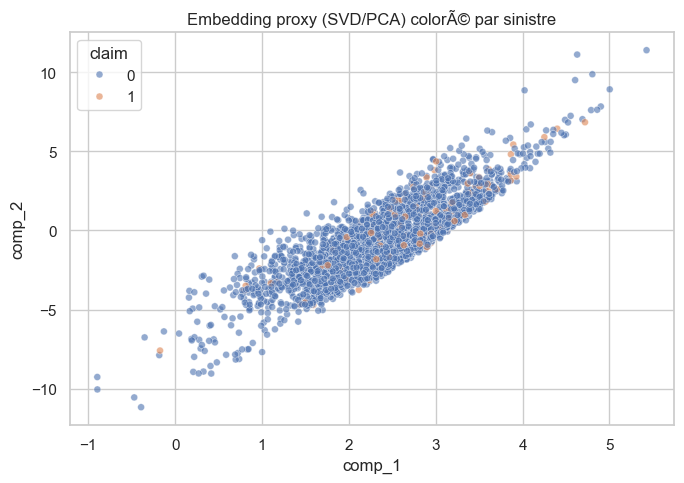

In [12]:
# RÃ©duction de dimension proxy FAMD/MCA (sans dÃ©pendance externe)
sample_df = sample_for_exploration(train_fe, n=SAMPLE_N, seed=SEED, stratify_col="type_contrat" if "type_contrat" in train_fe.columns else None)
sample_num = [c for c in sample_df.columns if str(sample_df[c].dtype).startswith(("int","float")) and c not in [v2.TARGET_FREQ_COL, v2.TARGET_SEV_COL]]
sample_cat = [c for c in sample_df.columns if sample_df[c].dtype == "object"]
emb = fit_mixed_embedding_proxy(sample_df, num_cols=sample_num, cat_cols=sample_cat, n_components=2)
emb_plot = emb.copy()
emb_plot["claim"] = (sample_df[v2.TARGET_SEV_COL].astype(float) > 0).astype(int).values
emb_plot["utilisation"] = sample_df["utilisation"].astype(str).values if "utilisation" in sample_df.columns else "NA"
emb_plot["type_contrat"] = sample_df["type_contrat"].astype(str).values if "type_contrat" in sample_df.columns else "NA"

plt.figure(figsize=(7,5))
sns.scatterplot(data=emb_plot, x="comp_1", y="comp_2", hue="claim", alpha=0.6, s=25)
plt.title("Embedding proxy (SVD/PCA) colorÃ© par sinistre")
plt.tight_layout()


In [13]:
# Clustering exploratoire (KMeans) sur reprÃ©sentation mixte encodÃ©e
from src.insurance_pricing.analytics import fit_kmeans_exploration

sample_num = [c for c in sample_df.columns if str(sample_df[c].dtype).startswith(("int","float")) and c not in [v2.TARGET_FREQ_COL, v2.TARGET_SEV_COL]]
sample_cat = [c for c in sample_df.columns if sample_df[c].dtype == "object"]
kmeans_df = fit_kmeans_exploration(sample_df, num_cols=sample_num, cat_cols=sample_cat, n_clusters=4, random_state=SEED)
sample_cluster = sample_df.join(kmeans_df)
cluster_summary = sample_cluster.groupby("cluster").agg(
    n=(v2.TARGET_SEV_COL, "size"),
    claim_rate=(v2.TARGET_SEV_COL, lambda s: float((pd.to_numeric(s, errors='coerce') > 0).mean())),
    pure_premium_obs=(v2.TARGET_SEV_COL, lambda s: float(pd.to_numeric(s, errors='coerce').fillna(0).mean())),
).reset_index()
display(cluster_summary)


,cluster,n,claim_rate,pure_premium_obs
0,0,801,0.052434,111.436155
1,1,519,0.102119,169.743179
2,2,569,0.029877,47.158120
3,3,1111,0.051305,94.232682


In [14]:
n_gower = 300 if QUICK_ANALYSIS else 800
gower_sample = sample_for_exploration(sample_df, n=n_gower, seed=SEED, stratify_col=None)
g_num = [c for c in gower_sample.columns if str(gower_sample[c].dtype).startswith(("int","float")) and c not in [v2.TARGET_FREQ_COL, v2.TARGET_SEV_COL]]
g_cat = [c for c in gower_sample.columns if gower_sample[c].dtype == "object"]
D = compute_gower_like_distance_sample(gower_sample, num_cols=g_num, cat_cols=g_cat)
print("distance matrix shape:", D.shape, "mean dist:", float(np.mean(D)))
link = compute_linkage_from_distance(D, method="average")
print("linkage shape:", link.shape)


distance matrix shape: (300, 300) mean dist: 0.42355268726464096
linkage shape: (299, 4)


**Ã€ commenter (segmentation / mining)**
- `Constat`: structures/amas potentiels dans les donnÃ©es mixtes.
- `InterprÃ©tation`: exploration descriptive, pas segmentation de production.
- `DÃ©cision`: rÃ©utiliser les patterns pour enrichir les features/segments mÃ©tier.


In [15]:
# Mapping preprocessing + recommandations
missing_report = compute_missingness_report(train_raw, test_raw, group_cols=None)
prep_reco = compute_preprocessing_recommendations(data_dict, cardinality, missing_report, postal_as_categorical=True)
display(prep_reco.head(50))
display(prep_reco[prep_reco["column"].isin(["code_postal","cp2","cp3","conducteur2","age_conducteur2","anciennete_permis2","poids_vehicule","cylindre_vehicule"])].sort_values("column"))


,column,role_guess,dtype_train,nunique_train,missing_rate_train,action,encoding,imputation,scaling,transform,special_handling,comment
0,id_client,id_group,object,45785.0,0.00000,exclude_feature,none,none,none,none,identifier,TE uniquement en CV cross-fit; IDs exclus; fea...
1,id_contrat,id_group,object,50000.0,0.00000,exclude_feature,none,none,none,none,identifier,TE uniquement en CV cross-fit; IDs exclus; fea...
2,id_vehicule,id_group,object,5.0,0.00000,exclude_feature,none,none,none,none,identifier,TE uniquement en CV cross-fit; IDs exclus; fea...
3,index,id_index,int64,50000.0,0.00000,exclude_feature,none,none,none,none,identifier,TE uniquement en CV cross-fit; IDs exclus; fea...
4,montant_sinistre,target_sev,float64,2260.0,0.00000,target_only,none,none,none,none,target_column,TE uniquement en CV cross-fit; IDs exclus; fea...
5,nombre_sinistres,target_freq,int64,2.0,0.00000,target_only,none,none,none,none,target_column,TE uniquement en CV cross-fit; IDs exclus; fea...
6,age_conducteur1,numeric,int64,83.0,0.00000,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,,TE uniquement en CV cross-fit; IDs exclus; fea...
7,age_conducteur2,numeric,int64,81.0,0.00000,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,conditional_missing_if_no_second_driver,TE uniquement en CV cross-fit; IDs exclus; fea...
8,anciennete_info,numeric,int64,25.0,0.00000,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,,TE uniquement en CV cross-fit; IDs exclus; fea...
9,anciennete_permis1,numeric,int64,79.0,0.00000,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,,TE uniquement en CV cross-fit; IDs exclus; fea...


,column,role_guess,dtype_train,nunique_train,missing_rate_train,action,encoding,imputation,scaling,transform,special_handling,comment
7,age_conducteur2,numeric,int64,81.0,0.0,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,conditional_missing_if_no_second_driver,TE uniquement en CV cross-fit; IDs exclus; fea...
10,anciennete_permis2,numeric,int64,71.0,0.0,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,conditional_missing_if_no_second_driver,TE uniquement en CV cross-fit; IDs exclus; fea...
13,code_postal,categorical,object,12790.0,0.0,use_feature,target_encoding_cv_or_catboost_rare_grouping,none_or_Unknown,none,rare_grouping_if_needed,categorical_hierarchy_cp2_cp3_fallback,TE uniquement en CV cross-fit; IDs exclus; fea...
14,conducteur2,categorical,object,2.0,0.0,use_feature,one_hot_or_catboost,none_or_Unknown,none,rare_grouping_if_needed,structural_missing_if_no_second_driver + indic...,TE uniquement en CV cross-fit; IDs exclus; fea...
15,cylindre_vehicule,numeric,int64,532.0,0.0,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,zero_technique_to_na + indicator,TE uniquement en CV cross-fit; IDs exclus; fea...
25,poids_vehicule,numeric,int64,968.0,0.0,use_feature,numeric,none_or_median,robust_scaler_if_distance_or_linear_model,none_or_binning_if_explainability,zero_technique_to_na + indicator,TE uniquement en CV cross-fit; IDs exclus; fea...


In [16]:
# RÃ¨gles de transformation appliquÃ©es / justifiÃ©es (cas mÃ©tier)
transform_rules = pd.DataFrame([
    {
        "feature_or_group": "code_postal / cp3 / cp2",
        "rule": "traiter comme hiÃ©rarchie catÃ©gorielle",
        "justification": "OOD fort au niveau code fin, plus stable sur agrÃ©gats gÃ©ographiques",
    },
    {
        "feature_or_group": "conducteur2 + variables conducteur2",
        "rule": "NA structurels + has_second_driver + imputation conditionnelle",
        "justification": "absence de conducteur2 n'est pas un missing alÃ©atoire",
    },
    {
        "feature_or_group": "poids_vehicule / cylindre_vehicule",
        "rule": "0 technique -> NA + indicateur",
        "justification": "zÃ©ro impossible physiquement / code technique",
    },
    {
        "feature_or_group": "montant_sinistre (positifs)",
        "rule": "log1p pour certaines familles + audit de queue",
        "justification": "asymÃ©trie forte et queue lourde",
    },
])
display(transform_rules)


,feature_or_group,rule,justification
0,code_postal / cp3 / cp2,traiter comme hiÃ©rarchie catÃ©gorielle,"OOD fort au niveau code fin, plus stable sur a..."
1,conducteur2 + variables conducteur2,NA structurels + has_second_driver + imputatio...,absence de conducteur2 n'est pas un missing al...
2,poids_vehicule / cylindre_vehicule,0 technique -> NA + indicateur,zÃ©ro impossible physiquement / code technique
3,montant_sinistre (positifs),log1p pour certaines familles + audit de queue,asymÃ©trie forte et queue lourde


In [17]:
# Catalogue de feature engineering (features existantes + blocs)
train_fe_v2, test_fe_v2 = v2.add_engineered_features_v2(train_raw, test_raw, rare_min_count=30)
fe_catalog = build_feature_engineering_catalog(train_fe_v2)
display(fe_catalog.head(100))


,feature,feature_block,rationale
0,bonus,contract_usage,feature brute utile au scoring
1,bonus_x_usage,contract_usage,interaction metier non lineaire
2,duree_contrat,contract_usage,feature brute utile au scoring
3,freq_paiement,contract_usage,feature brute utile au scoring
4,is_paiement_yes,contract_usage,signal binaire / gestion missing / OOD
5,paiement,contract_usage,feature brute utile au scoring
6,type_contrat,contract_usage,feature brute utile au scoring
7,utilisation,contract_usage,feature brute utile au scoring
8,age_conducteur1,driver,feature brute utile au scoring
9,age_conducteur2,driver,feature brute utile au scoring


In [18]:
# Ablations via artefacts V2 (si disponibles)
fs_cmp_path = ARTIFACT_V2 / "feature_set_comparison_v2.csv"
if fs_cmp_path.exists():
    fs_cmp = pd.read_csv(fs_cmp_path)
    sort_cols = [c for c in ["rmse_prime","q99_ratio_pos","rmse_gap_secondary","rmse_gap_aux"] if c in fs_cmp.columns]
    ascending = [True, False, True, True][: len(sort_cols)]
    display(fs_cmp.sort_values(sort_cols, ascending=ascending).head(30) if sort_cols else fs_cmp.head(30))
    cmp_cols = [c for c in ["feature_set","split","rmse_prime","q99_ratio_pos","rmse_gap_secondary","rmse_gap_aux"] if c in fs_cmp.columns]
    if cmp_cols:
        display(fs_cmp[cmp_cols].pivot_table(index="feature_set", columns="split", values="rmse_prime", aggfunc="mean"))
else:
    print("Artifact absent:", fs_cmp_path)


,level,split,feature_set,engine,family,tweedie_power,config_id,seed,severity_mode,calibration,...,run_id,rmse_gap_secondary,rmse_gap_aux,pred_q99_test,pred_q90_test,pred_q99_oof_primary,q99_test_over_oof_primary,distribution_collapse_flag,tail_dispersion_flag,experiment
5,run,primary_time,robust_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,isotonic,...,robust_v2|catboost|two_part_classic|1.5|cb_v2_...,NaN,NaN,442.115714,215.412093,522.115490,0.846778,0,0,robust_with_te
1,run,primary_time,base_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,isotonic,...,base_v2|catboost|two_part_classic|1.5|cb_v2_c1...,NaN,NaN,441.346275,212.297916,528.626555,0.834892,0,0,base_with_te
7,run,primary_time,compact_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,isotonic,...,compact_v2|catboost|two_part_classic|1.5|cb_v2...,NaN,NaN,464.644212,210.989583,566.985011,0.819500,0,0,compact_with_te
4,run,primary_time,robust_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,none,...,robust_v2|catboost|two_part_classic|1.5|cb_v2_...,NaN,NaN,484.567322,237.663151,575.735634,0.841649,0,0,robust_with_te
2,run,primary_time,base_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,none,...,base_v2|catboost|two_part_classic|1.5|cb_v2_c1...,NaN,NaN,416.226641,209.587871,588.144846,0.707694,0,1,base_no_te
6,run,primary_time,compact_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,none,...,compact_v2|catboost|two_part_classic|1.5|cb_v2...,NaN,NaN,506.548992,231.805444,628.838716,0.805531,0,0,compact_with_te
3,run,primary_time,base_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,isotonic,...,base_v2|catboost|two_part_classic|1.5|cb_v2_c1...,NaN,NaN,427.690047,214.159364,617.469765,0.692649,0,1,base_no_te
0,run,primary_time,base_v2,catboost,two_part_classic,1.5,cb_v2_c1,42,weighted_tail,none,...,base_v2|catboost|two_part_classic|1.5|cb_v2_c1...,NaN,NaN,555.615277,238.674505,671.953058,0.826866,0,0,base_with_te


split,primary_time
feature_set,
base_v2,557.562273
compact_v2,556.011073
robust_v2,554.351875


In [19]:
# Features candidates Ã  tester V3 (priorisÃ©es par constats EDA)
v3_candidates = pd.DataFrame([
    {"feature_candidate": "vehicule_residual_score (cross-fit)", "hypothese": "capturer effet vÃ©hicule non expliquÃ© par base two-part", "risque": "surapprentissage si fuite"},
    {"feature_candidate": "zone_x_type_vehicule", "hypothese": "interaction gÃ©ographie Ã— profil de vÃ©hicule", "risque": "cardinalitÃ© / sparsitÃ©"},
    {"feature_candidate": "bonus_x_usage", "hypothese": "effet bonus diffÃ©rent selon usage", "risque": "redondance"},
    {"feature_candidate": "power_weight_band", "hypothese": "proxy segment de risque vÃ©hicule plus stable", "risque": "discrÃ©tisation arbitraire"},
    {"feature_candidate": "ood_flags_postal_modele", "hypothese": "amÃ©liore robustesse test OOD", "risque": "signal faible si mal calibrÃ©"},
])
display(v3_candidates)


,feature_candidate,hypothese,risque
0,vehicule_residual_score (cross-fit),capturer effet vÃ©hicule non expliquÃ© par bas...,surapprentissage si fuite
1,zone_x_type_vehicule,interaction gÃ©ographie Ã— profil de vÃ©hicule,cardinalitÃ© / sparsitÃ©
2,bonus_x_usage,effet bonus diffÃ©rent selon usage,redondance
3,power_weight_band,proxy segment de risque vÃ©hicule plus stable,discrÃ©tisation arbitraire
4,ood_flags_postal_modele,amÃ©liore robustesse test OOD,signal faible si mal calibrÃ©


In [20]:
# Exports d'analyse (Notebook 2)
segment_exports = {f"segment_target_{k}": v for k, v in seg_tables.items()}
tables = {
    "preprocessing_recommendations": prep_reco,
    "preprocessing_rules_catalog": transform_rules,
    "feature_engineering_catalog": fe_catalog,
    "feature_candidates_v3": v3_candidates,
    "cardinality_report": cardinality,
    **segment_exports,
}
export_analysis_tables(tables, ARTIFACT_DS)
print("Exports DS notebook 2 ->", ARTIFACT_DS)


Exports DS notebook 2 -> C:\Users\icemo\Downloads\Calcul-prime-d-assurance\artifacts\ds


## SynthÃ¨se Notebook 2 (Ã  complÃ©ter)

- Features / transformations retenues:
  - [ ] ...
- Features / transformations rejetÃ©es (et pourquoi):
  - [ ] ...
- Prochaines validations cÃ´tÃ© modÃ¨le:
  - [ ] queue de sÃ©vÃ©ritÃ©
  - [ ] calibration frÃ©quence
  - [ ] biais par segment


## Export standardis? des sorties DS (CSV + PNG)

Cette cellule sauvegarde les tables et figures dans `artifacts/ds/` via `ds_reporting`.


In [21]:
# DS_OUTPUT_EXPORT_CELL_V1
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from src.insurance_pricing.runtime.ds_reporting import save_table, save_figure, export_ds_tables_and_figures

NOTEBOOK_NAME = '08_ds_eda_segmentation_preprocessing.ipynb'
DS_ROOT = Path('artifacts/ds')

# Export tables disponibles (compat notebooks existants)
for csv_path in sorted(DS_ROOT.glob('*.csv')):
    try:
        df = pd.read_csv(csv_path)
        save_table(df, csv_path.stem, NOTEBOOK_NAME)
    except Exception:
        pass

# Figure l?g?re de synth?se (si m?triques dispo)
metrics_path = DS_ROOT / 'oof_model_diagnostics_metrics.csv'
if metrics_path.exists():
    m = pd.read_csv(metrics_path)
    if not m.empty and 'q99_ratio_pos' in m.columns:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        q = pd.to_numeric(m['q99_ratio_pos'], errors='coerce').dropna()
        if len(q):
            ax.plot(range(len(q)), q, marker='o')
            ax.axhline(1.0, linestyle='--', color='red', linewidth=1)
            ax.set_title('q99_ratio_pos - diagnostic')
            ax.set_xlabel('run')
            ax.set_ylabel('ratio')
            save_figure(fig, 'q99_ratio_pos_notebook', NOTEBOOK_NAME, dpi=160)
        plt.close(fig)

# Export batch standardis?
_ = export_ds_tables_and_figures(mode='full')
print('DS exports updated for', NOTEBOOK_NAME)



DS exports updated for 08_ds_eda_segmentation_preprocessing.ipynb
